# Imports and Hardware setup

This cell will initialize PyTorch and insures that this computer(Mac)'s GPU[Metal Performance Shaders] will handle the training load.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchaudio
from torch.utils.data import DataLoader, random_split
import numpy as np

# Route to Apple Silicon GPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("- Metal Performance Shaders (MPS) backend enabled! Training on Mac GPU.")
else:
    device = torch.device("cpu")
    print("- MPS not found. Defaulting to CPU.")

- Metal Performance Shaders (MPS) backend enabled! Training on Mac GPU.


# Load the Processed Dataset

This will pull *.pt* file we created in the data preprocessing notebook and splits it into training and testing batches.

In [2]:
from torch.utils.data import DataLoader, random_split

WORKING_DATA_PATH = "./processed_working_dataset.pt"
BATCH_SIZE = 32

print("Loading working dataset into memory...")
# We only load the working dataset. The Kenyan demo dataset stays safely on disk!
working_dataset = torch.load(WORKING_DATA_PATH, weights_only=False)
working_size = len(working_dataset)

# 80/10/10 Split
train_size = int(0.8 * working_size)
val_size = int(0.1 * working_size)
test_size = working_size - train_size - val_size

# A manual seed ensures the split is perfectly reproducible
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset, test_dataset = random_split(
    working_dataset, 
    [train_size, val_size, test_size],
    generator=generator
)

# Initialize DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("--- Data Distribution ---")
print(f"Training batches: {len(train_loader)} ({train_size} samples)")
print(f"Validation batches: {len(val_loader)} ({val_size} samples)")
print(f"Testing batches: {len(test_loader)} ({test_size} samples)")

Loading working dataset into memory...
--- Data Distribution ---
Training batches: 99 (3156 samples)
Validation batches: 13 (394 samples)
Testing batches: 13 (395 samples)


# The Full Architecture

With the use of 2D Convolutions to properly capture the frequency-time structure of the MFCC matrices, adds SpecAugment directly into the pipeline to prevent overfitting, and incorporates an Attention Pooling layer instead of just taking the final LSTM time step. 

In [8]:
import torch
import torch.nn as nn
import torchaudio
import torchaudio.transforms as T

class SpecAugmentPipeline(nn.Module):
    """Applies frequency and time masking to prevent overfitting to background noise."""
    def __init__(self, freq_mask_param=15, time_mask_param=35):
        super().__init__()
        self.freq_mask = T.FrequencyMasking(freq_mask_param=freq_mask_param)
        self.time_mask = T.TimeMasking(time_mask_param=time_mask_param)

    def forward(self, x):
        if self.training:
            x = self.freq_mask(x)
            x = self.time_mask(x)
        return x


class AttentionPooling(nn.Module):
    """Dynamically weights important time steps containing mosquito flight tones."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, lstm_output):
        # lstm_output shape: (batch, seq_len, hidden_dim)
        weights = torch.softmax(self.attention(lstm_output), dim=1) # (batch, seq_len, 1)
        context = torch.sum(weights * lstm_output, dim=1)            # (batch, hidden_dim)
        return context


class MosquitoAttnNet(nn.Module):
    def __init__(self, num_classes=2, sample_rate=8000, n_mfcc=40):
        super(MosquitoAttnNet, self).__init__()
        
        # 1. MFCC Feature Extractor
        self.mfcc = torchaudio.transforms.MFCC(
            sample_rate=sample_rate,
            n_mfcc=n_mfcc,
            melkwargs={'n_fft': 256, 'hop_length': 80, 'n_mels': 64}
        )
        
        # 2. SpecAugment regularization (only active during model.train())
        self.spec_augment = SpecAugmentPipeline()
        
        # 3. 2D Convolutional Backbone (Treats MFCC like a 1-channel image: [batch, 1, n_mfcc, time])
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d((2, 2))
        
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d((2, 2))
        
        self.relu = nn.LeakyReLU(0.2)
        self.dropout = nn.Dropout(0.4)
        
        # 4. Bi-directional LSTM for temporal pattern capture
        # After two max pooling layers on n_mfcc=40, feature dimension becomes: (40 / 4) * 64 = 640
        self.lstm = nn.LSTM(input_size=640, hidden_size=128, num_layers=2, 
                            batch_first=True, bidirectional=True, dropout=0.3)
        
        # 5. Self-Attention Pooling (hidden_size * 2 due to bidirectional LSTM = 256)
        self.attention_pool = AttentionPooling(hidden_dim=256)
        
        # 6. Final Classification Head
        self.fc = nn.Sequential(
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        if x.dim() == 3:
            x = x.squeeze(1)
            
        # Extract MFCC -> Shape: (batch, n_mfcc, time_frames)
        x = self.mfcc(x)
        
        # Add channel dimension for 2D Conv -> Shape: (batch, 1, n_mfcc, time_frames)
        x = x.unsqueeze(1)
        x = self.spec_augment(x)
        
        # Pass through 2D CNN layers
        x = self.pool1(self.bn1(self.relu(self.conv1(x))))
        x = self.pool2(self.bn2(self.relu(self.conv2(x))))
        
        # Reshape for LSTM: collapse frequency and channel dimensions into features
        # Shape becomes: (batch, time_frames, channels * remaining_mels)
        b, c, m, t = x.shape
        x = x.permute(0, 3, 1, 2).contiguous().view(b, t, c * m)
        
        # LSTM sequence processing
        lstm_out, _ = self.lstm(x)
        
        # Attention Pooling over all time steps
        x = self.attention_pool(lstm_out)
        x = self.dropout(x)
        
        return self.fc(x)

# Compile V6 Architecture
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = MosquitoAttnNet(num_classes=2).to(device)
print("Upgraded V6 2D-CNN + BiLSTM + Attention architecture compiled successfully!")

Upgraded V6 2D-CNN + BiLSTM + Attention architecture compiled successfully!


# The Training Loop

This cell will train the model by looping over the batches, calculating the errors(loss), and adjusting the network weights to improve the accuracy.

In [9]:
# Dynamically calculate weights based on the actual distribution of your working dataset
all_labels = working_dataset.tensors[1] 
class_counts = torch.bincount(all_labels)
total_samples = len(all_labels)

# Formula for balanced class weights: Total Samples / (Number of Classes * Class Count)
weight_class_0 = total_samples / (2.0 * class_counts[0].float())
weight_class_1 = total_samples / (2.0 * class_counts[1].float())

penalty_weights = torch.tensor([weight_class_0, weight_class_1], dtype=torch.float32).to(device)
print(f"Computed Penalty Weights -> Class 0 (Safe): {weight_class_0:.2f} | Class 1 (Vector): {weight_class_1:.2f}")

criterion = nn.CrossEntropyLoss(weight=penalty_weights)

# Hyperparameters
EPOCHS = 40  
LEARNING_RATE = 0.0005

# Define optimizer and scheduler
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print("Starting training phase for Malaria_detector_Net_V6 with Validation...")

best_val_loss = float('inf')

for epoch in range(EPOCHS):
    # --- 1. TRAINING PHASE ---
    model.train()
    running_train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        
    epoch_train_loss = running_train_loss / len(train_loader)
    epoch_train_acc = 100 * train_correct / train_total
    
    # --- 2. VALIDATION PHASE ---
    model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_acc = 100 * val_correct / val_total
    
    # Step the scheduler based on the VALIDATION loss
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(epoch_val_loss)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] | LR: {current_lr:.6f} | "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")
          
    # --- 3. AUTO-SAVER (Model Checkpoint) ---
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "Malaria_detector_Net_V6.pth")
        print(f"   => Validation loss improved. Saved best model to Malaria_detector_Net_V6.pth")

print("=> Training Complete!")

Computed Penalty Weights -> Class 0 (Safe): 1.47 | Class 1 (Vector): 0.76
Starting training phase for Malaria_detector_Net_V6 with Validation...
Epoch [1/40] | LR: 0.000500 | Train Loss: 0.4988 | Train Acc: 69.30% | Val Loss: 0.4071 | Val Acc: 72.08%
   => Validation loss improved. Saved best model to Malaria_detector_Net_V6.pth
Epoch [2/40] | LR: 0.000500 | Train Loss: 0.4248 | Train Acc: 75.86% | Val Loss: 0.3994 | Val Acc: 81.22%
   => Validation loss improved. Saved best model to Malaria_detector_Net_V6.pth
Epoch [3/40] | LR: 0.000500 | Train Loss: 0.4098 | Train Acc: 79.02% | Val Loss: 0.3886 | Val Acc: 76.90%
   => Validation loss improved. Saved best model to Malaria_detector_Net_V6.pth
Epoch [4/40] | LR: 0.000500 | Train Loss: 0.3961 | Train Acc: 79.18% | Val Loss: 0.4013 | Val Acc: 81.22%
Epoch [5/40] | LR: 0.000500 | Train Loss: 0.3765 | Train Acc: 81.08% | Val Loss: 0.3710 | Val Acc: 82.23%
   => Validation loss improved. Saved best model to Malaria_detector_Net_V6.pth
Epoch

Evaluating model on the testing dataset...


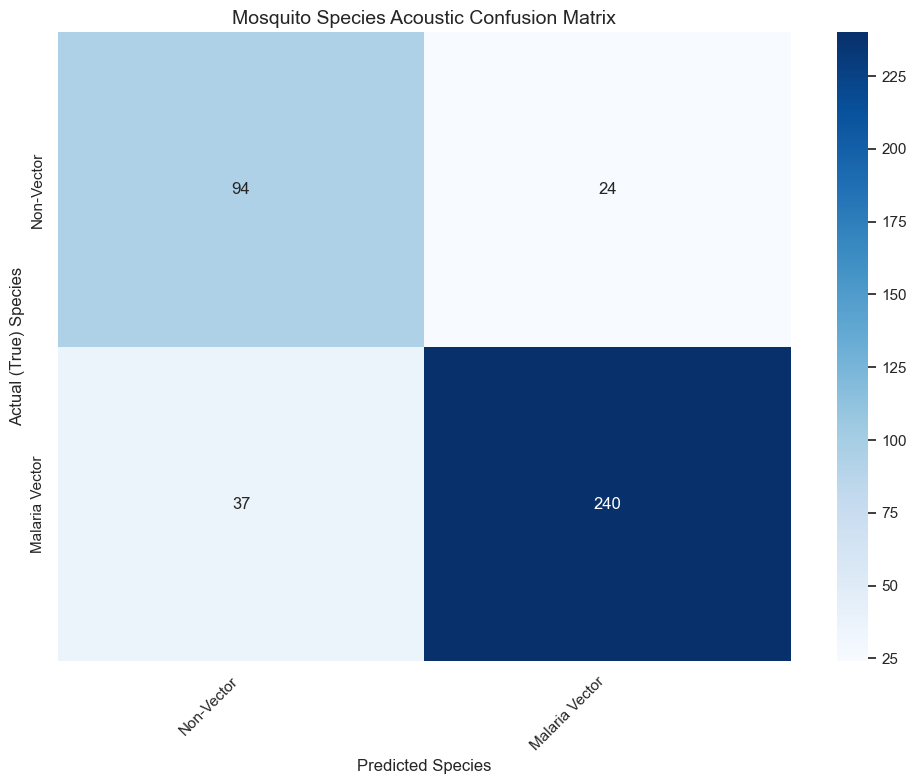


--- Detailed Classification Report ---
                precision    recall  f1-score   support

    Non-Vector       0.72      0.80      0.76       118
Malaria Vector       0.91      0.87      0.89       277

      accuracy                           0.85       395
     macro avg       0.81      0.83      0.82       395
  weighted avg       0.85      0.85      0.85       395



In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Ensure the model is in evaluation mode (turns off Dropout)
model.eval()

all_preds = []
all_labels = []

print("Evaluating model on the testing dataset...")

# Disable gradient calculation for testing to save memory and speed up execution
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# The exact target species from your preprocessing notebook
target_names = ['Non-Vector', 'Malaria Vector']

# Generate and plot the Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)

plt.title('Mosquito Species Acoustic Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Species', fontsize=12)
plt.ylabel('Actual (True) Species', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print the detailed statistical breakdown
print("\n--- Detailed Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=target_names, zero_division=0))

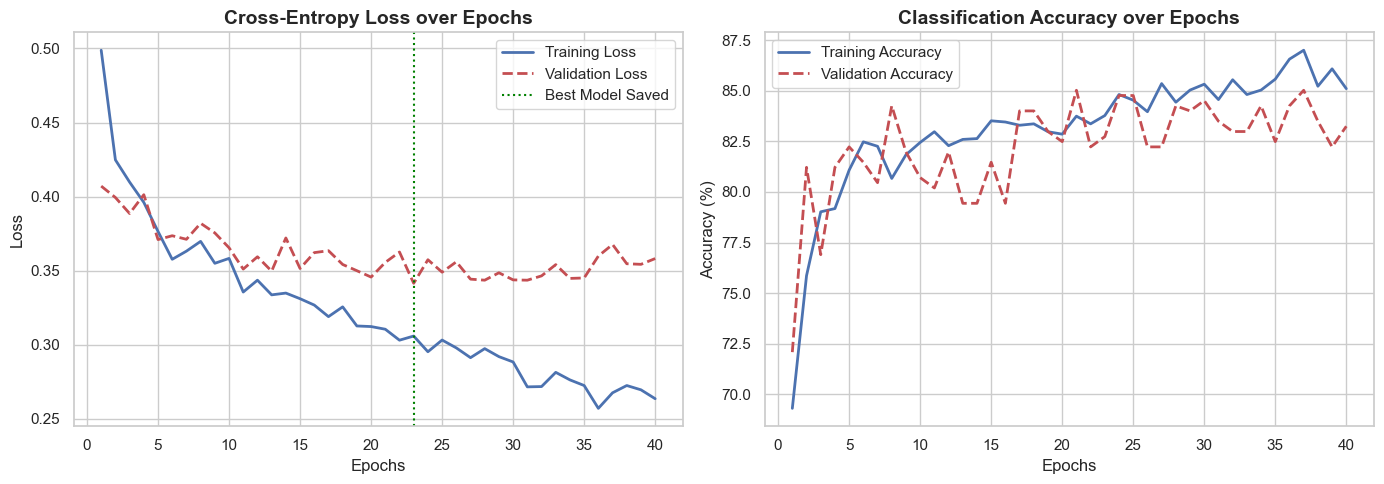

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1. Paste your entire training output inside these triple quotes
log_text = """
Epoch [1/40] | LR: 0.000500 | Train Loss: 0.4988 | Train Acc: 69.30% | Val Loss: 0.4071 | Val Acc: 72.08%
   => Validation loss improved. Saved best model to Malaria_detector_Net_V6.pth
Epoch [2/40] | LR: 0.000500 | Train Loss: 0.4248 | Train Acc: 75.86% | Val Loss: 0.3994 | Val Acc: 81.22%
   => Validation loss improved. Saved best model to Malaria_detector_Net_V6.pth
Epoch [3/40] | LR: 0.000500 | Train Loss: 0.4098 | Train Acc: 79.02% | Val Loss: 0.3886 | Val Acc: 76.90%
   => Validation loss improved. Saved best model to Malaria_detector_Net_V6.pth
Epoch [4/40] | LR: 0.000500 | Train Loss: 0.3961 | Train Acc: 79.18% | Val Loss: 0.4013 | Val Acc: 81.22%
Epoch [5/40] | LR: 0.000500 | Train Loss: 0.3765 | Train Acc: 81.08% | Val Loss: 0.3710 | Val Acc: 82.23%
   => Validation loss improved. Saved best model to Malaria_detector_Net_V6.pth
Epoch [6/40] | LR: 0.000500 | Train Loss: 0.3577 | Train Acc: 82.48% | Val Loss: 0.3736 | Val Acc: 81.47%
Epoch [7/40] | LR: 0.000500 | Train Loss: 0.3632 | Train Acc: 82.26% | Val Loss: 0.3712 | Val Acc: 80.46%
Epoch [8/40] | LR: 0.000500 | Train Loss: 0.3698 | Train Acc: 80.67% | Val Loss: 0.3820 | Val Acc: 84.26%
Epoch [9/40] | LR: 0.000500 | Train Loss: 0.3550 | Train Acc: 81.84% | Val Loss: 0.3755 | Val Acc: 81.98%
Epoch [10/40] | LR: 0.000250 | Train Loss: 0.3583 | Train Acc: 82.45% | Val Loss: 0.3655 | Val Acc: 80.71%
   => Validation loss improved. Saved best model to Malaria_detector_Net_V6.pth
Epoch [11/40] | LR: 0.000250 | Train Loss: 0.3356 | Train Acc: 82.98% | Val Loss: 0.3511 | Val Acc: 80.20%
   => Validation loss improved. Saved best model to Malaria_detector_Net_V6.pth
Epoch [12/40] | LR: 0.000250 | Train Loss: 0.3436 | Train Acc: 82.29% | Val Loss: 0.3594 | Val Acc: 81.98%
Epoch [13/40] | LR: 0.000250 | Train Loss: 0.3337 | Train Acc: 82.60% | Val Loss: 0.3497 | Val Acc: 79.44%
   => Validation loss improved. Saved best model to Malaria_detector_Net_V6.pth
Epoch [14/40] | LR: 0.000250 | Train Loss: 0.3349 | Train Acc: 82.64% | Val Loss: 0.3721 | Val Acc: 79.44%
Epoch [15/40] | LR: 0.000250 | Train Loss: 0.3311 | Train Acc: 83.52% | Val Loss: 0.3515 | Val Acc: 81.47%
Epoch [16/40] | LR: 0.000250 | Train Loss: 0.3268 | Train Acc: 83.46% | Val Loss: 0.3622 | Val Acc: 79.44%
Epoch [17/40] | LR: 0.000250 | Train Loss: 0.3190 | Train Acc: 83.30% | Val Loss: 0.3635 | Val Acc: 84.01%
Epoch [18/40] | LR: 0.000125 | Train Loss: 0.3256 | Train Acc: 83.37% | Val Loss: 0.3542 | Val Acc: 84.01%
Epoch [19/40] | LR: 0.000125 | Train Loss: 0.3127 | Train Acc: 82.98% | Val Loss: 0.3500 | Val Acc: 82.99%
Epoch [20/40] | LR: 0.000125 | Train Loss: 0.3123 | Train Acc: 82.86% | Val Loss: 0.3457 | Val Acc: 82.49%
   => Validation loss improved. Saved best model to Malaria_detector_Net_V6.pth
Epoch [21/40] | LR: 0.000125 | Train Loss: 0.3105 | Train Acc: 83.75% | Val Loss: 0.3556 | Val Acc: 85.03%
Epoch [22/40] | LR: 0.000125 | Train Loss: 0.3031 | Train Acc: 83.37% | Val Loss: 0.3626 | Val Acc: 82.23%
Epoch [23/40] | LR: 0.000125 | Train Loss: 0.3059 | Train Acc: 83.78% | Val Loss: 0.3415 | Val Acc: 82.74%
   => Validation loss improved. Saved best model to Malaria_detector_Net_V6.pth
Epoch [24/40] | LR: 0.000125 | Train Loss: 0.2953 | Train Acc: 84.82% | Val Loss: 0.3574 | Val Acc: 84.77%
Epoch [25/40] | LR: 0.000125 | Train Loss: 0.3032 | Train Acc: 84.54% | Val Loss: 0.3490 | Val Acc: 84.77%
Epoch [26/40] | LR: 0.000125 | Train Loss: 0.2979 | Train Acc: 83.97% | Val Loss: 0.3560 | Val Acc: 82.23%
Epoch [27/40] | LR: 0.000125 | Train Loss: 0.2913 | Train Acc: 85.36% | Val Loss: 0.3443 | Val Acc: 82.23%
Epoch [28/40] | LR: 0.000063 | Train Loss: 0.2974 | Train Acc: 84.44% | Val Loss: 0.3436 | Val Acc: 84.26%
Epoch [29/40] | LR: 0.000063 | Train Loss: 0.2920 | Train Acc: 85.04% | Val Loss: 0.3486 | Val Acc: 84.01%
Epoch [30/40] | LR: 0.000063 | Train Loss: 0.2884 | Train Acc: 85.33% | Val Loss: 0.3438 | Val Acc: 84.52%
Epoch [31/40] | LR: 0.000063 | Train Loss: 0.2716 | Train Acc: 84.57% | Val Loss: 0.3436 | Val Acc: 83.50%
Epoch [32/40] | LR: 0.000031 | Train Loss: 0.2718 | Train Acc: 85.55% | Val Loss: 0.3465 | Val Acc: 82.99%
Epoch [33/40] | LR: 0.000031 | Train Loss: 0.2814 | Train Acc: 84.82% | Val Loss: 0.3541 | Val Acc: 82.99%
Epoch [34/40] | LR: 0.000031 | Train Loss: 0.2763 | Train Acc: 85.04% | Val Loss: 0.3448 | Val Acc: 84.26%
Epoch [35/40] | LR: 0.000031 | Train Loss: 0.2725 | Train Acc: 85.58% | Val Loss: 0.3451 | Val Acc: 82.49%
Epoch [36/40] | LR: 0.000016 | Train Loss: 0.2571 | Train Acc: 86.57% | Val Loss: 0.3599 | Val Acc: 84.26%
Epoch [37/40] | LR: 0.000016 | Train Loss: 0.2676 | Train Acc: 87.01% | Val Loss: 0.3677 | Val Acc: 85.03%
Epoch [38/40] | LR: 0.000016 | Train Loss: 0.2725 | Train Acc: 85.23% | Val Loss: 0.3547 | Val Acc: 83.50%
Epoch [39/40] | LR: 0.000016 | Train Loss: 0.2696 | Train Acc: 86.09% | Val Loss: 0.3543 | Val Acc: 82.23%
Epoch [40/40] | LR: 0.000008 | Train Loss: 0.2636 | Train Acc: 85.11% | Val Loss: 0.3582 | Val Acc: 83.25%
"""

# 2. Parse the metrics using Regex
train_loss = [float(x) for x in re.findall(r'Train Loss: ([\d.]+)', log_text)]
val_loss = [float(x) for x in re.findall(r'Val Loss: ([\d.]+)', log_text)]
train_acc = [float(x) for x in re.findall(r'Train Acc: ([\d.]+)%', log_text)]
val_acc = [float(x) for x in re.findall(r'Val Acc: ([\d.]+)%', log_text)]
epochs = range(1, len(train_loss) + 1)

# 3. Render the Visualizations
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss
ax1.plot(epochs, train_loss, 'b-', label='Training Loss', linewidth=2)
ax1.plot(epochs, val_loss, 'r--', label='Validation Loss', linewidth=2)
ax1.axvline(x=val_loss.index(min(val_loss))+1, color='green', linestyle=':', label='Best Model Saved')
ax1.set_title('Cross-Entropy Loss over Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

# Plot Accuracy
ax2.plot(epochs, train_acc, 'b-', label='Training Accuracy', linewidth=2)
ax2.plot(epochs, val_acc, 'r--', label='Validation Accuracy', linewidth=2)
ax2.set_title('Classification Accuracy over Epochs', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()

plt.tight_layout()
plt.show()

Evaluating model on 1335 unseen Kenyan field recordings...


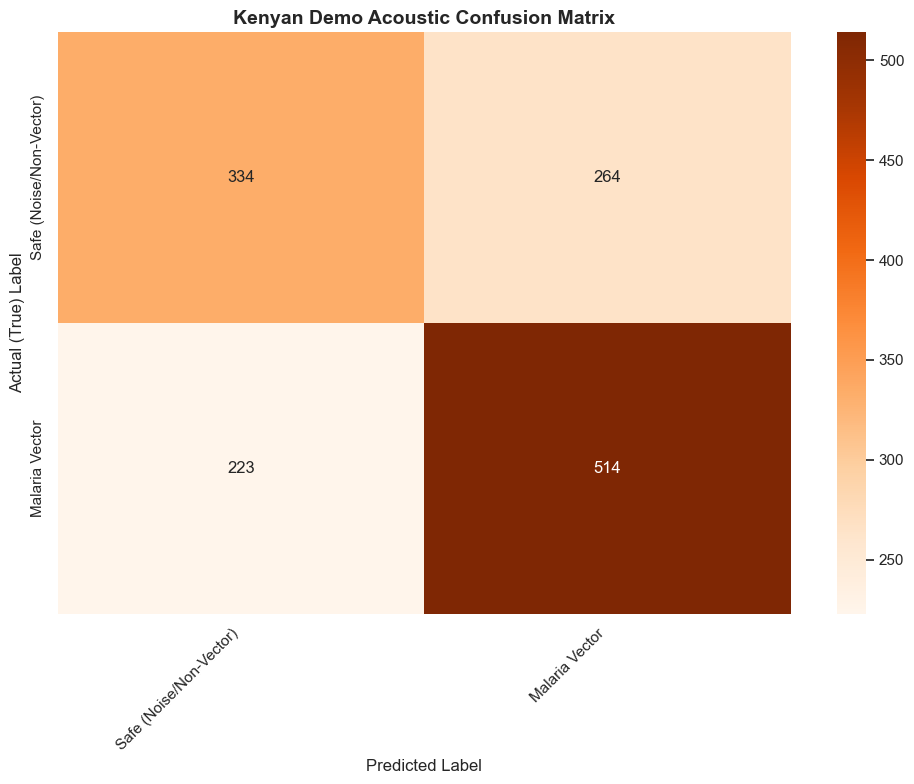


- Kenyan Demo Classification Report -
                         precision    recall  f1-score   support

Safe (Noise/Non-Vector)       0.60      0.56      0.58       598
         Malaria Vector       0.66      0.70      0.68       737

               accuracy                           0.64      1335
              macro avg       0.63      0.63      0.63      1335
           weighted avg       0.63      0.64      0.63      1335



In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report

# 1. Hardware and Model Setup
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = MosquitoAttnNet(num_classes=2).to(device)
model.load_state_dict(torch.load("Malaria_detector_Net_V6.pth", map_location=device, weights_only=True))
model.eval() # Disable dropout for inference

# 2. Load the Isolated Kenyan Demo Dataset
DEMO_DATA_PATH = "./humbugdb_demo_kenya.pt"
demo_dataset = torch.load(DEMO_DATA_PATH, weights_only=False)
demo_loader = DataLoader(demo_dataset, batch_size=32, shuffle=False)

print(f"Evaluating model on {len(demo_dataset)} unseen Kenyan field recordings...")

# 3. Inference Loop
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in demo_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 4. Generate the Confusion Matrix
target_names = ['Safe (Noise/Non-Vector)', 'Malaria Vector']
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=target_names, 
            yticklabels=target_names)

plt.title('Kenyan Demo Acoustic Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual (True) Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 5. Print Detailed Statistical Breakdown
print("\n- Kenyan Demo Classification Report -")
print(classification_report(all_labels, all_preds, target_names=target_names, zero_division=0))